# EDGAR EDA: Insider Trading & Corporate Filings

**Watchlist:** Apple · Alphabet (Google) · Tesla · NVIDIA · BlackRock · Oracle · OpenAI

This notebook uses [`edgartools`](https://github.com/dgunning/edgartools) to explore what the SEC's EDGAR system
reveals about these companies, and which parts of it are worth building an investment tool around.

| Section | EDGAR source | Question |
|---|---|---|
| 1. Company profiles | Submissions API | Who are these filers and how big are they? |
| 2. Filing activity | Filing index, 8-K items | What do they file, and how often do material events happen? |
| 3. Insider trading | **Form 4** | Are executives buying, selling, or just vesting? |
| 4. Fundamentals | **XBRL financials** (10-K) | How do revenue, profit and cash flow trend? |
| 5. Institutional ownership | **13F-HR** (BlackRock) | How is the largest asset manager positioned in the other names? |
| 6. Private markets | **Form D** (OpenAI) | What can EDGAR tell us about a company that isn't public? |
| 7. Insights | – | Which EDGAR data makes a great investment tool? |

> **Two data quirks before we start**
> * **OpenAI is private.** It files no 10-K, 10-Q or Form 4. Its EDGAR footprint is the **Form D**
>   filings of the SPVs and feeder funds that buy its shares, which Section 6 uses.
> * **BlackRock changed CIKs.** After the 2024 GIP acquisition, the listed parent became a new holding company
>   (CIK `2012383`). The ticker lookup resolves to the new entity, so its XBRL history starts in FY2023.

In [3]:
pip install edgar

132.14s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [edgar]
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip uninstall -y edgar edgartools
!pip install edgartools


247.36s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Found existing installation: edgar 5.6.3
Uninstalling edgar-5.6.3:
  Successfully uninstalled edgar-5.6.3


252.87s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 20.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: textdistance
    Found existing installation: textdistance 4.2.1
    Uninstalling textdistance-4.2.1:
      Successfully uninstalled textdistance-4.2.1
  Attempting uninstall: filelock
    Found existing installation: filelock 3.17.0
    Uninstalling filelock-3.17.0:
      Successfully uninstalled filelock-3.17.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [edgartools]0 [edgartools]


In [2]:
from concurrent.futures import ThreadPoolExecutor
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from edgar import Company, search_filings, set_identity

# SEC requires a User-Agent with contact info on every request
set_identity("grantmodels.ai@gmail.com")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

TODAY = date.today()
INSIDER_START = TODAY - timedelta(days=365)       # 12-month insider window
FILINGS_START = TODAY - timedelta(days=3 * 365)   # 3-year filing-activity window

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

PUBLIC = {
    "AAPL": "Apple",
    "GOOGL": "Alphabet",
    "TSLA": "Tesla",
    "NVDA": "NVIDIA",
    "BLK": "BlackRock",
    "ORCL": "Oracle",
}

# Fixed color per company, so an entity keeps its color in every chart
COLORS = dict(zip(PUBLIC, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]))

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})

def usd(x, _=None):
    # Compact dollar formatter for axes and tables
    x = float(x)
    if pd.isna(x):
        return ""
    for div, suf in [(1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "K")]:
        if abs(x) >= div:
            return f"${x / div:,.1f}{suf}"
    return f"${x:,.0f}"

companies = {t: Company(t) for t in PUBLIC}

## 1. Company profiles
The submissions endpoint gives each filer's identity: CIK, SIC industry code, fiscal year end, filer status,
and (from the latest 10-K/10-Q cover page) shares outstanding and public float.

In [2]:
def profile(ticker, c):
    return {
        "ticker": ticker,
        "name": c.name,
        "cik": c.cik,
        "sic": c.sic,
        "industry": c.industry,
        "fiscal_year_end": c.fiscal_year_end,
        "large_accelerated": c.is_large_accelerated_filer,
        "shares_outstanding": c.shares_outstanding,
        "public_float": c.public_float,
    }

profiles = pd.DataFrame([profile(t, c) for t, c in companies.items()]).set_index("ticker")
profiles.style.format({"shares_outstanding": "{:,.0f}", "public_float": usd})

,name,cik,sic,industry,fiscal_year_end,large_accelerated,shares_outstanding,public_float
ticker,,,,,,,,
AAPL,Apple Inc.,320193,3571,Electronic Computers,0926,True,"14,594,180,000",$3.3T
GOOGL,Alphabet Inc.,1652044,7370,"Services-Computer Programming, Data Processing, Etc.",1231,True,"12,230,000,000",$1.9T
TSLA,"Tesla, Inc.",1318605,3711,Motor Vehicles & Passenger Car Bodies,1231,True,"3,949,547,394",$550.2B
NVDA,NVIDIA CORP,1045810,3674,Semiconductors & Related Devices,0131,True,"24,100,000,000",$4.0T
BLK,"BlackRock, Inc.",2012383,6211,"Security Brokers, Dealers & Flotation Companies",1231,True,"154,926,181",$159.0B
ORCL,ORACLE CORP,1341439,7372,Services-Prepackaged Software,0531,True,"3,023,736,000",$346.8B


## 2. Filing activity
How each company uses EDGAR says a lot about what it is. We pull every filing from the last three years
and count them by form type.

In [3]:
def filing_index(ticker):
    df = companies[ticker].get_filings().filter(date=f"{FILINGS_START}:").to_pandas()
    df["ticker"] = ticker
    return df

filings = pd.concat([filing_index(t) for t in PUBLIC], ignore_index=True)
filings["filing_date"] = pd.to_datetime(filings["filing_date"])

form_mix = (filings.groupby(["form", "ticker"]).size().unstack(fill_value=0)[list(PUBLIC)])
form_mix = form_mix.loc[form_mix.sum(axis=1).sort_values(ascending=False).index].head(15)
form_mix

ticker,AAPL,GOOGL,TSLA,NVDA,BLK,ORCL
form,,,,,,
SCHEDULE 13G/A,2,5,4,4,3022,1
4,136,511,82,315,208,158
SC 13G/A,3,6,3,4,984,2
SCHEDULE 13G,1,2,1,3,736,0
144,43,249,60,233,29,58
SC 13G,0,0,0,1,639,0
8-K,26,40,33,32,24,28
DEFA14A,3,4,79,3,7,3
PX14A6G,11,19,21,2,0,2


**Reading the form mix**
* **Form 4** dominates for the operating companies. Every insider grant, sale, tax withholding and gift is a filing.
* **Form 144** is a *notice of proposed sale* by an affiliate. It often lands **before** the matching Form 4, which makes it
  a leading indicator of insider selling.
* **BlackRock is different.** Most of its filings are **SC 13G / 13G/A**, reports that it crossed 5% ownership of *other*
  companies. BlackRock files less *about itself* than about everyone it owns.
* **424B2 / FWP** (Apple, Oracle) are debt-issuance prospectuses. Frequent bond deals show a company funding buybacks or
  capex with debt. Oracle's AI data-center buildout is the example to watch here.

**What this run found (filings since 2023-09-29):**
* **BlackRock filed about 5,400 Schedule 13G / 13G/A reports** in three years, more than every other form combined,
  while filing only 6 10-Qs about itself.
* **Tesla filed 79 DEFA14A** (additional proxy material), far more than any peer. That is the paper trail of its
  contested shareholder votes on Musk's pay package and reincorporation. Proxy-fight volume is a governance-risk flag.
* **Alphabet and NVIDIA file 13F-HRs** because they are *investors* too (Alphabet through GV/CapitalG, NVIDIA
  through its equity portfolio). NVIDIA's 13F is a free, quarterly map of which AI companies it backs.
* **Form 144 volume** (Alphabet 249, NVIDIA 233) previews the insider selling in Section 3.

### 8-K material events
8-Ks are filed within four business days of a material event, and each is tagged with **item codes**. The most
investment-relevant are:

| Item | Meaning |
|---|---|
| 1.01 | Entered a material definitive agreement |
| 2.02 | Results of operations (earnings release) |
| 5.02 | Departure / appointment of directors or officers |
| 5.07 | Shareholder vote results |
| 7.01 / 8.01 | Reg FD disclosure / other events |

In [4]:
ITEM_LABELS = {
    "1.01": "1.01 Material agreement", "2.02": "2.02 Earnings", "2.03": "2.03 New debt obligation",
    "5.02": "5.02 Exec/director change", "5.07": "5.07 Shareholder vote", "7.01": "7.01 Reg FD",
    "8.01": "8.01 Other events", "9.01": "9.01 Exhibits",
}

eight_k = filings[filings["form"] == "8-K"].copy()
eight_k["item"] = eight_k["items"].fillna("").str.split(",")
item_counts = (eight_k.explode("item")
               .assign(item=lambda d: d["item"].str.strip())
               .query("item in @ITEM_LABELS")
               .groupby(["item", "ticker"]).size().unstack(fill_value=0)
               .reindex(columns=list(PUBLIC), fill_value=0)
               .rename(index=ITEM_LABELS))
item_counts

ticker,AAPL,GOOGL,TSLA,NVDA,BLK,ORCL
item,,,,,,
1.01 Material agreement,0,2,2,1,4,2
2.02 Earnings,12,12,24,12,8,12
2.03 New debt obligation,0,0,1,1,4,0
5.02 Exec/director change,7,9,4,9,5,7
5.07 Shareholder vote,3,3,2,3,2,3
7.01 Reg FD,2,2,1,1,9,4
8.01 Other events,1,23,1,7,5,18
9.01 Exhibits,16,28,30,15,20,23


Item **5.02** (leadership change) is the one to alert on. Executive departures often come before strategy shifts or
guidance resets, and the count above shows which companies have had the most management turnover.

## 3. Insider trading (Form 4)
Officers, directors and 10% owners must report trades within **two business days** on Form 4. Transaction codes
separate signal from noise:

| Code | Meaning | Signal? |
|---|---|---|
| **P** | Open-market purchase | **Strongest.** Insiders spend their own cash |
| **S** | Open-market sale | Weak alone: diversification, taxes. Stronger when clustered or *not* under a 10b5-1 plan |
| A | Grant / award | None, it's compensation |
| F | Shares withheld for tax | None, mechanical |
| M | Option / RSU exercise | Neutral |
| G | Gift | Usually estate planning |

We parse every Form 4 from the last 12 months. Results are cached to `data/insider_trades.csv` so reruns are fast.

In [5]:
CACHE = DATA_DIR / "insider_trades.csv"

def parse_form4(ticker, filing):
    try:
        f4 = filing.obj()
    except Exception as exc:  # malformed / amended XML
        print(f"skip {ticker} {filing.accession_no}: {exc}")
        return None
    # A filer's list can include Form 4s where the company is the *owner* (e.g. BlackRock as 10% holder)
    if int(f4.issuer.cik) != int(companies[ticker].cik):
        return None
    df = f4.to_dataframe()
    if df.empty:
        return None
    df["ticker"] = ticker
    df["filing_date"] = filing.filing_date
    df["accession"] = filing.accession_no
    df["is_10b5_1"] = bool(f4.aff10b5_one)
    return df

def load_insider_trades(refresh=False):
    if CACHE.exists() and not refresh:
        return pd.read_csv(CACHE, parse_dates=["Date", "filing_date"])
    frames = []
    for ticker in PUBLIC:
        f4s = companies[ticker].get_filings(form="4").filter(date=f"{INSIDER_START}:")
        with ThreadPoolExecutor(max_workers=4) as pool:
            frames += [d for d in pool.map(lambda f: parse_form4(ticker, f), f4s) if d is not None]
        print(f"{ticker}: {len(f4s)} Form 4 filings")
    out = pd.concat(frames, ignore_index=True)
    out.to_csv(CACHE, index=False)
    return pd.read_csv(CACHE, parse_dates=["Date", "filing_date"])

trades = load_insider_trades()
for col in ["Shares", "Price", "Value", "Remaining Shares"]:
    trades[col] = pd.to_numeric(trades[col], errors="coerce")
trades["Value"] = trades["Value"].fillna(trades["Shares"] * trades["Price"])
print(f"{len(trades):,} transactions from {trades['accession'].nunique():,} filings")
trades.head()

1,753 transactions from 485 filings


,Transaction Type,Code,Description,Shares,Price,Value,Date,Form,Issuer,Ticker,Insider,Position,Remaining Shares,ticker,filing_date,accession,is_10b5_1,Remarks
0,Derivative_Purchase,A,Grant/Award (Common Stock),"47,645.00",NaN,NaN,2026-09-27,Form 4,Apple Inc.,AAPL,Sabih Khan,COO,NaN,AAPL,2026-09-29,0001140361-26-038028,False,NaN
1,Derivative_Purchase,A,Grant/Award (Common Stock),"47,645.00",NaN,NaN,2026-09-27,Form 4,Apple Inc.,AAPL,Sabih Khan,COO,NaN,AAPL,2026-09-29,0001140361-26-038028,False,NaN
2,Derivative_Purchase,A,Grant/Award (Common Stock),"47,645.00",NaN,NaN,2026-09-27,Form 4,Apple Inc.,AAPL,Jennifer Newstead,"SVP, GC and Government Affairs",NaN,AAPL,2026-09-29,0001140361-26-038027,False,NaN
3,Derivative_Purchase,A,Grant/Award (Common Stock),"47,645.00",NaN,NaN,2026-09-27,Form 4,Apple Inc.,AAPL,Jennifer Newstead,"SVP, GC and Government Affairs",NaN,AAPL,2026-09-29,0001140361-26-038027,False,NaN
4,Derivative_Purchase,A,Grant/Award (Common Stock),"47,645.00",NaN,NaN,2026-09-27,Form 4,Apple Inc.,AAPL,Deirdre O'Brien,Senior Vice President,NaN,AAPL,2026-09-29,0001140361-26-038026,False,NaN


In [6]:
CODE_LABELS = {"P": "Buy (P)", "S": "Sell (S)", "A": "Award (A)", "F": "Tax withhold (F)",
               "M": "Exercise (M)", "G": "Gift (G)", "C": "Conversion (C)"}

by_code = (trades.assign(code=trades["Code"].map(CODE_LABELS).fillna("Other"))
           .pivot_table(index="ticker", columns="code", values="Shares", aggfunc="count", fill_value=0)
           .reindex(list(PUBLIC)))
by_code

code,Award (A),Conversion (C),Exercise (M),Gift (G),Other,Sell (S),Tax withhold (F)
ticker,,,,,,,
AAPL,30,0,59,4,0,36,15
GOOGL,200,184,0,63,0,258,130
TSLA,2,0,22,3,1,66,1
NVDA,28,0,0,14,5,329,22
BLK,81,0,8,9,0,42,10
ORCL,22,0,50,3,5,29,20


### Open-market activity: the part that matters
We keep only **P** and **S** trades and split the sales by whether the filing was made under a **Rule 10b5-1 plan**
(pre-scheduled, so less informative) or was discretionary.

In [7]:
market = trades[trades["Code"].isin(["P", "S"])].copy()
market["side"] = market["Code"].map({"P": "Buy", "S": "Sell"})
market["plan"] = market["is_10b5_1"].map({True: "10b5-1 plan", False: "Discretionary"})

summary = (market.groupby(["ticker", "side"])["Value"].sum().unstack(fill_value=0)
           .reindex(index=list(PUBLIC), columns=["Buy", "Sell"], fill_value=0))
summary["Net"] = summary["Buy"] - summary["Sell"]
summary["Sellers"] = market[market.side == "Sell"].groupby("ticker")["Insider"].nunique()
summary["Buyers"] = market[market.side == "Buy"].groupby("ticker")["Insider"].nunique()
summary["% sold via 10b5-1"] = (market[market.side == "Sell"]
                                .groupby("ticker")
                                .apply(lambda d: d.loc[d.is_10b5_1, "Value"].sum() / d["Value"].sum()))
summary = summary.fillna(0)
summary.style.format({"Buy": usd, "Sell": usd, "Net": usd, "Sellers": "{:.0f}",
                      "Buyers": "{:.0f}", "% sold via 10b5-1": "{:.0%}"})

side,Buy,Sell,Net,Sellers,Buyers,% sold via 10b5-1
ticker,,,,,,
AAPL,$0,$173.9M,$-173.9M,8,0,50%
GOOGL,$0,$153.7M,$-153.7M,6,0,100%
TSLA,$0,$87.7M,$-87.7M,4,0,65%
NVDA,$0,$2.2B,$-2.2B,12,0,30%
BLK,$0,$206.1M,$-206.1M,8,0,0%
ORCL,$0,$119.7M,$-119.7M,9,0,70%


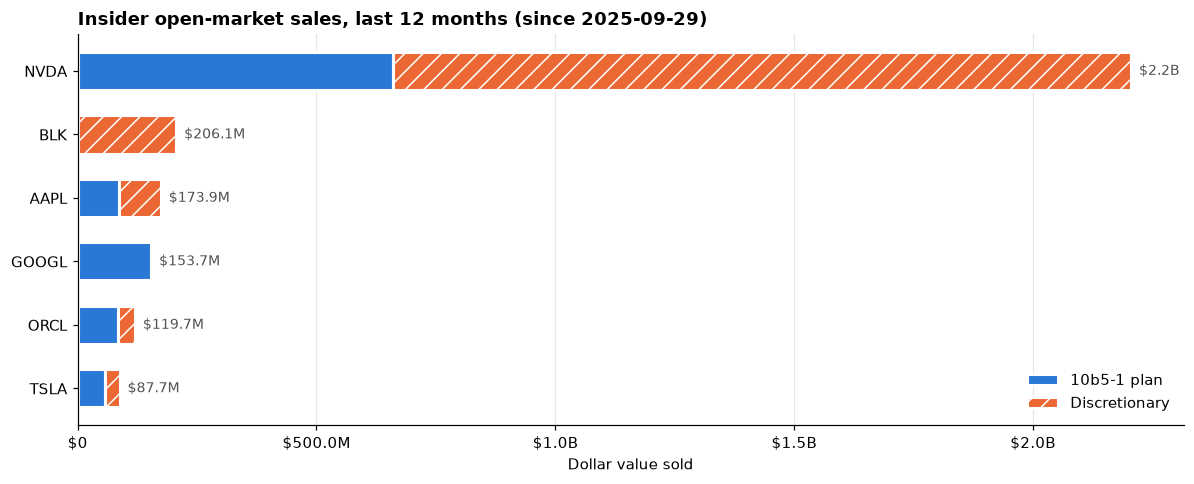

In [8]:
sells = (market[market.side == "Sell"].groupby(["ticker", "plan"])["Value"].sum()
         .unstack(fill_value=0).reindex(index=list(PUBLIC), fill_value=0)
         .reindex(columns=["10b5-1 plan", "Discretionary"], fill_value=0))
sells = sells.loc[sells.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(11, 4.5))
left = pd.Series(0.0, index=sells.index)
for col, color, hatch in [("10b5-1 plan", "#2a78d6", None), ("Discretionary", "#eb6834", "//")]:
    ax.barh(sells.index, sells[col], left=left, color=color, hatch=hatch, height=0.6,
            edgecolor="white", linewidth=2, label=col)
    left += sells[col]
for y, total in enumerate(sells.sum(axis=1)):
    ax.text(total, y, "  " + usd(total), va="center", fontsize=9, color="#52514e")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(usd))
ax.set_title(f"Insider open-market sales, last 12 months (since {INSIDER_START})")
ax.set_xlabel("Dollar value sold")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [9]:
top_sellers = (market[market.side == "Sell"]
               .groupby(["ticker", "Insider", "Position"])
               .agg(sold=("Value", "sum"), shares=("Shares", "sum"), trades=("Value", "size"),
                    pct_plan=("is_10b5_1", "mean"), last_sale=("Date", "max"))
               .sort_values("sold", ascending=False).head(15))
top_sellers.style.format({"sold": usd, "shares": "{:,.0f}", "pct_plan": "{:.0%}"})

**What this run found (last 12 months):**
* **Zero open-market purchases** by any insider at any of the six companies. Every open-market trade was a sale.
* **NVIDIA insiders sold about $2.2B**, more than the other five combined. Most of it was one director (Mark Stevens,
  about $1.5B) selling **outside** a 10b5-1 plan.
* **BlackRock reported 0% of its insider sales under 10b5-1**, while Alphabet reported 100%. Same activity, very
  different information content.

### Timing: monthly insider selling
Selling clusters in the **open trading windows** after each earnings release (8-K Item 2.02). A spike *outside*
the usual window, or several insiders selling at once, is worth a closer look.

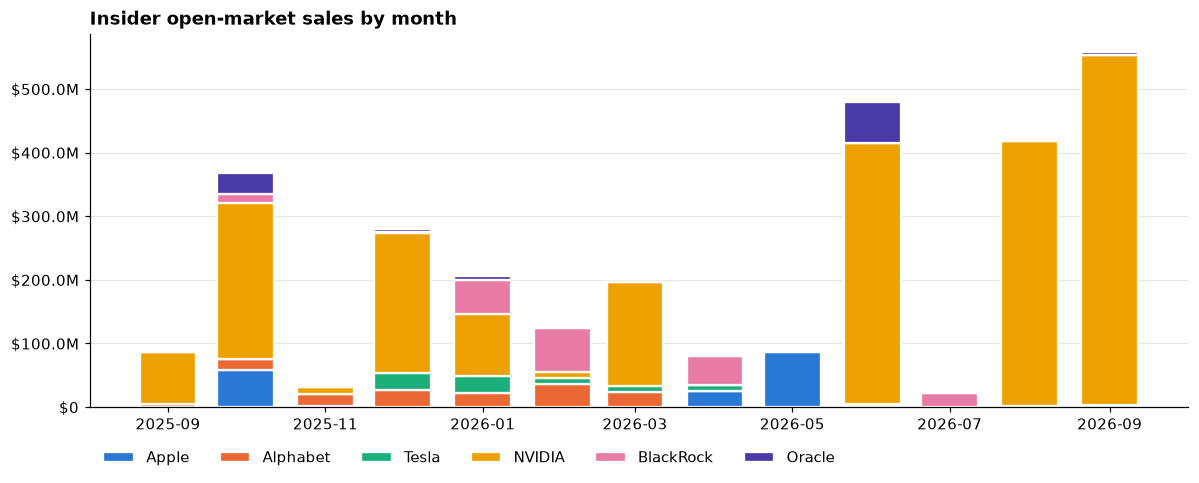

In [10]:
monthly = (market[market.side == "Sell"]
           .assign(month=lambda d: d["Date"].dt.to_period("M").dt.to_timestamp())
           .pivot_table(index="month", columns="ticker", values="Value", aggfunc="sum", fill_value=0)
           .reindex(columns=[t for t in PUBLIC if t in market.ticker.unique()]))

fig, ax = plt.subplots(figsize=(11, 4.5))
bottom = pd.Series(0.0, index=monthly.index)
for t in monthly.columns:
    ax.bar(monthly.index, monthly[t], bottom=bottom, width=22, color=COLORS[t],
           edgecolor="white", linewidth=1.5, label=PUBLIC[t])
    bottom += monthly[t]
ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd))
ax.set_title("Insider open-market sales by month")
ax.legend(frameon=False, ncol=6, loc="upper left", bbox_to_anchor=(0, -0.08))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### Insider selling relative to company size
Raw dollar amounts are misleading: a founder selling $1B of a $4T company differs from a CFO selling $50M of
a $200B company. Dividing shares sold by shares outstanding (from the cover page) normalizes the flow.

In [11]:
relative = pd.DataFrame({
    "shares_sold": market[market.side == "Sell"].groupby("ticker")["Shares"].sum(),
    "shares_outstanding": profiles["shares_outstanding"],
}).reindex(list(PUBLIC)).fillna(0)
relative["% of shares outstanding"] = relative["shares_sold"] / relative["shares_outstanding"]
relative.sort_values("% of shares outstanding", ascending=False).style.format(
    {"shares_sold": "{:,.0f}", "shares_outstanding": "{:,.0f}", "% of shares outstanding": "{:.3%}"})

,shares_sold,shares_outstanding,% of shares outstanding
ticker,,,
BLK,"187,216","154,926,181",0.121%
NVDA,"10,761,319","24,100,000,000",0.045%
ORCL,"644,643","3,023,736,000",0.021%
TSLA,"207,882","3,949,547,394",0.005%
AAPL,"636,958","14,594,180,000",0.004%
GOOGL,"514,223","12,230,000,000",0.004%


## 4. Fundamentals from XBRL
Since 2009 every 10-K/10-Q has carried machine-readable **XBRL** tags. edgartools standardizes the concepts, so
`RevenueFromContractWithCustomerExcludingAssessedTax` and `NetIncomeLoss` can be compared across companies with no
PDF scraping. Note the fiscal calendars: NVIDIA's FY ends in late January and Oracle's in May, so their
"FY 2026" is already reported.

In [12]:
def annual(ticker, concept):
    df = companies[ticker].income_statement(periods=5, as_dataframe=True)
    fy_cols = [c for c in df.columns if str(c).startswith("FY")]
    return df.loc[concept, fy_cols] if concept in df.index else pd.Series(dtype=float)

REV, NI = "RevenueFromContractWithCustomerExcludingAssessedTax", "NetIncomeLoss"
fund = pd.concat({t: pd.DataFrame({"revenue": annual(t, REV), "net_income": annual(t, NI)}) for t in PUBLIC},
                 names=["ticker", "fiscal_year"]).reset_index()
fund["fy"] = fund["fiscal_year"].str.extract(r"(\d{4})").astype(int)
fund["net_margin"] = fund["net_income"] / fund["revenue"]
fund = fund.sort_values(["ticker", "fy"])
fund["revenue_growth"] = fund.groupby("ticker")["revenue"].pct_change()

fund.pivot(index="fy", columns="ticker", values="revenue")[list(PUBLIC)].style.format(usd)

ticker,AAPL,GOOGL,TSLA,NVDA,BLK,ORCL
fy,,,,,,
2021,$365.8B,$257.6B,$53.8B,,,
2022,$394.3B,$282.8B,$81.5B,$26.9B,,$42.4B
2023,$383.3B,$307.4B,$96.8B,$27.0B,$17.9B,$50.0B
2024,$391.0B,$350.0B,$97.7B,$60.9B,$20.4B,$53.0B
2025,$416.2B,$402.8B,$94.8B,$130.5B,$24.2B,$57.4B
2026,,,,$215.9B,,$67.4B


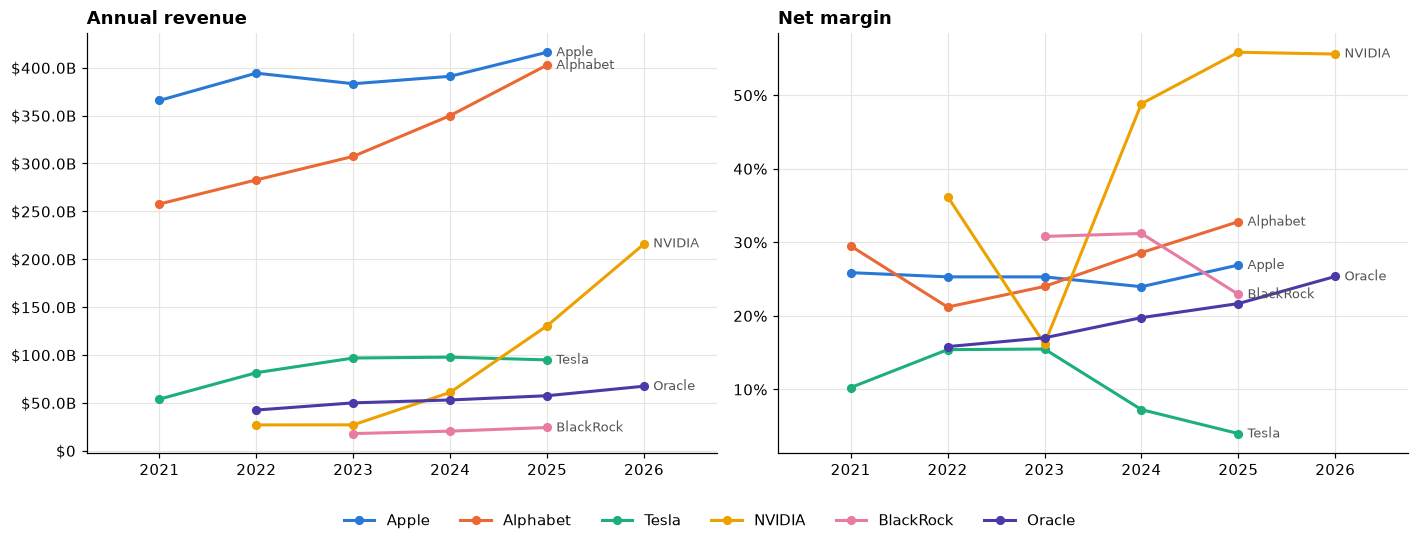

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for t in PUBLIC:
    d = fund[fund.ticker == t]
    for ax, col in zip(axes, ["revenue", "net_margin"]):
        ax.plot(d["fy"], d[col], color=COLORS[t], lw=2, marker="o", ms=5, label=PUBLIC[t])
        ax.annotate(PUBLIC[t], (d["fy"].iloc[-1], d[col].iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=8.5, color="#52514e")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(usd))
axes[0].set_title("Annual revenue")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Net margin")
for ax in axes:
    ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
    ax.margins(x=0.15)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, ncol=6, loc="lower center",
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

In [14]:
metrics = pd.DataFrame({t: companies[t].get_financials().get_financial_metrics() for t in PUBLIC}).T
metrics["fcf_margin"] = metrics["free_cash_flow"] / metrics["revenue"]
metrics["capex_to_ocf"] = metrics["capital_expenditures"] / metrics["operating_cash_flow"]
cols = ["revenue", "net_income", "operating_cash_flow", "capital_expenditures", "free_cash_flow",
        "fcf_margin", "capex_to_ocf", "current_ratio", "debt_to_assets"]
metrics[cols].style.format({**{c: usd for c in cols[:5]}, "fcf_margin": "{:.0%}", "capex_to_ocf": "{:.0%}",
                            "current_ratio": "{:.2f}", "debt_to_assets": "{:.2f}"})

,revenue,net_income,operating_cash_flow,capital_expenditures,free_cash_flow,fcf_margin,capex_to_ocf,current_ratio,debt_to_assets
AAPL,$416.2B,$112.0B,$111.5B,$12.7B,$98.8B,24%,11%,0.89,0.79
GOOGL,$402.8B,$132.2B,$164.7B,$91.4B,$73.3B,18%,56%,2.01,0.30
TSLA,$94.8B,$3.8B,$14.7B,$8.5B,$6.2B,7%,58%,2.16,0.40
NVDA,$215.9B,$120.1B,$102.7B,$6.0B,$96.7B,45%,6%,3.91,0.24
BLK,$24.2B,$5.6B,$3.9B,$375.0M,$3.6B,15%,10%,nan,0.64
ORCL,$67.4B,$17.1B,$32.0B,$55.7B,$-23.7B,-35%,174%,1.12,nan


**What this run found:**
* **Oracle spent about 174% of its operating cash flow on capex**, which made its free cash flow **negative (about -$24B)**.
  Its 424B2 / FWP debt filings in Section 2 show how that spending is funded.
* **Alphabet (56%) and Tesla (58%)** reinvest more than half of their operating cash flow. **NVIDIA (6%) and Apple (11%)**
  reinvest very little, so their free cash flow is mostly available for buybacks.
* **NVIDIA's revenue grew about 3.5x in two fiscal years with net margins above 55%.** Tesla's net margin fell from
  about 15% (2023) to about 4% (2025).

**`capex_to_ocf`** is the key column for the AI trade. It shows how much operating cash flow each company is
reinvesting in data centers and hardware. A hyperscaler whose capex eats most of its operating cash flow is
betting its free cash flow on AI demand. NVIDIA is on the *receiving* end of that spending.

## 5. Institutional ownership: BlackRock's 13F
Managers with more than $100M of US equities file **13F-HR** quarterly, listing every position. BlackRock's is one
of the largest filings on EDGAR (roughly 50k rows before aggregation). We use it to see how BlackRock is
positioned in the other five names and how that changed quarter over quarter.

In [15]:
thirteen_f = companies["BLK"].get_filings(form="13F-HR")[0].obj()
print(f"Report period: {thirteen_f.report_period} | total 13F value: {usd(float(thirteen_f.total_value))} "
      f"| positions: {thirteen_f.total_holdings:,}")

holdings = thirteen_f.holdings.copy()
holdings = holdings[holdings["PutCall"].fillna("").eq("")]  # common stock, not options
holdings["ticker"] = holdings["Ticker"].replace({"GOOG": "GOOGL"})  # combine Alphabet share classes
watch = (holdings[holdings["ticker"].isin(PUBLIC)]
         .groupby("ticker")[["SharesPrnAmount", "Value"]].sum()
         .reindex(list(PUBLIC)))
watch["% of BLK 13F"] = watch["Value"] / float(thirteen_f.total_value)
watch["% of company"] = watch["SharesPrnAmount"] / profiles["shares_outstanding"]
watch.sort_values("Value", ascending=False).style.format(
    {"SharesPrnAmount": "{:,.0f}", "Value": usd, "% of BLK 13F": "{:.2%}", "% of company": "{:.2%}"})

Report period: 2026-06-30 | total 13F value: $6.7T | positions: 49,968


,SharesPrnAmount,Value,% of BLK 13F,% of company
ticker,,,,
NVDA,"1,941,918,386",$388.6B,5.77%,8.06%
AAPL,"1,162,996,939",$336.5B,5.00%,7.97%
GOOGL,"830,895,305",$295.4B,4.39%,6.79%
TSLA,"214,123,129",$90.1B,1.34%,5.42%
ORCL,"145,353,687",$21.3B,0.32%,4.81%
BLK,"10,137,544",$9.7B,0.14%,6.54%


### Quarter-over-quarter change
`compare_holdings()` matches rows by CUSIP, which mixes option and share lines for the same issuer. Here we
aggregate common-stock shares per ticker in the prior quarter's 13F and compare them directly.

In [16]:
def watchlist_positions(tf):
    h = tf.holdings
    h = h[h["PutCall"].fillna("").eq("")]
    return (h.assign(ticker=h["Ticker"].replace({"GOOG": "GOOGL"}))
            .query("ticker in @PUBLIC")
            .groupby("ticker")["SharesPrnAmount"].sum())

prev_13f = companies["BLK"].get_filings(form="13F-HR")[1].obj()
qoq = pd.DataFrame({f"shares {prev_13f.report_period}": watchlist_positions(prev_13f),
                    f"shares {thirteen_f.report_period}": watchlist_positions(thirteen_f)}).reindex(list(PUBLIC))
qoq["change"] = qoq.iloc[:, 1] - qoq.iloc[:, 0]
qoq["change %"] = qoq["change"] / qoq.iloc[:, 0]
qoq.style.format({c: "{:,.0f}" for c in qoq.columns[:2]} | {"change": "{:+,.0f}", "change %": "{:+.2%}"})

,shares 2026-03-31,shares 2026-06-30,change,change %
ticker,,,,
AAPL,"1,144,695,425","1,162,996,939","+18,301,514",+1.60%
GOOGL,"811,739,294","830,895,305","+19,156,011",+2.36%
TSLA,"208,095,009","214,123,129","+6,028,120",+2.90%
NVDA,"1,925,533,174","1,941,918,386","+16,385,212",+0.85%
BLK,"10,132,776","10,137,544","+4,768",+0.05%
ORCL,"143,310,374","145,353,687","+2,043,313",+1.43%


Most of BlackRock's book is **index funds**, so share-count changes mostly track fund flows and index weights, not
stock picking. The value of the 13F lies elsewhere:
* It shows **how concentrated passive ownership is**. BlackRock alone holds about 5–8% of every company here,
  including about 6.5% of *itself* through its own index funds.
* Repeated across *many* 13F filers, the same query becomes a **smart-money tracker**: which active managers
  opened or closed a position this quarter. The same `compare_holdings()` call works for any fund.
* **This run:** BlackRock *added* shares in all six names last quarter (+0.9% to +2.9%), consistent with index-fund
  inflows rather than a view on any one company.
* The 45-day filing lag means 13Fs confirm trends; they don't give timing signals.

## 6. OpenAI: reading a private company through Form D
OpenAI has no public filings, but anyone raising money under Regulation D must file a **Form D**. Many SPVs and
feeder funds exist only to buy OpenAI shares on the secondary market, and their names say so. EDGAR full-text
search finds them.

In [17]:
results = search_filings('"OpenAI"', forms="D", limit=100)
print(f"{results.total} Form D filings mention OpenAI")

def form_d_row(filing):
    try:
        od = filing.obj().offering_data
    except Exception:
        return None
    amt = od.offering_sales_amounts
    return {
        "filed": pd.Timestamp(filing.filing_date),
        "issuer": filing.company,
        "amount_offered": pd.to_numeric(amt.total_offering_amount, errors="coerce"),
        "amount_sold": pd.to_numeric(amt.total_amount_sold, errors="coerce"),
        "investors": pd.to_numeric(od.investors.total_already_invested, errors="coerce"),
        "min_investment": pd.to_numeric(od.minimum_investment, errors="coerce"),
    }

with ThreadPoolExecutor(max_workers=4) as pool:
    form_d = pd.DataFrame([r for r in pool.map(form_d_row, results.to_filings()) if r])
form_d = form_d.sort_values("filed")
# "OpenAI Startup Fund" entities are OpenAI's own VC arm (investing *in* startups), not demand for OpenAI stock
form_d["vehicle"] = form_d["issuer"].str.contains("OpenAI Startup Fund", case=False).map(
    {True: "OpenAI's own VC fund", False: "SPV buying OpenAI"})
print(form_d.groupby("vehicle").agg(filings=("issuer", "size"), amount_sold=("amount_sold", "sum"),
                                    investors=("investors", "sum")).to_string())
form_d.tail(15).style.format({"amount_offered": usd, "amount_sold": usd, "min_investment": usd,
                              "investors": "{:,.0f}", "filed": "{:%Y-%m-%d}"})

47 Form D filings mention OpenAI
                      filings  amount_sold  investors
vehicle                                              
OpenAI's own VC fund       12    754449472         32
SPV buying OpenAI          35    551151076        719


,filed,issuer,amount_offered,amount_sold,investors,min_investment,vehicle
44,2025-10-08,OpenAI Fund a Series of CGF2021 LLC (CIK 0002090214),$470.0K,$470.0K,15,$0,SPV buying OpenAI
37,2025-11-18,OPENAI - FUTURUM A SERIES OF MASTER FUND I LLC (CIK 0002041780),$500.0K,$500.0K,2,$250.0K,SPV buying OpenAI
7,2026-01-08,OpenAI Tender Fund I Sep 2025 a Series of CGF2021 LLC (CIK 0002101065),$312.0K,$312.0K,17,$0,SPV buying OpenAI
46,2026-03-12,OpenAI - Team Ignite Feb 2026 a Series of CGF2021 LLC (CIK 0002117288),$1.2M,$1.2M,32,$0,SPV buying OpenAI
40,2026-03-13,OpenAI Feb 2026 a Series of CGF2021 LLC (CIK 0002119969),$104.5K,$104.5K,19,$0,SPV buying OpenAI
12,2026-03-24,OpenAI-s a Series of GatePass Ventures I LLC (CIK 0002122816),$489.8K,$489.8K,14,$0,SPV buying OpenAI
36,2026-03-25,Kaleida Capital OpenAI SPV I a Series of CGF2021 LLC (CIK 0002122813),$500.0K,$500.0K,5,$0,SPV buying OpenAI
35,2026-04-10,VM OpenAI 1 a Series of PCXS LLC (CIK 0002102195),$2.9M,$2.9M,0,$0,SPV buying OpenAI
32,2026-04-14,ELSA Capital OpenAI SPV I a Series of CGF2021 LLC (CIK 0002127135),$2.0M,$2.0M,20,$0,SPV buying OpenAI
8,2026-04-23,OurCrowd (Investment in G-new OpenAI) L.P. (CIK 0002130942),$500.0K,$247.1K,15,$10.0K,SPV buying OpenAI


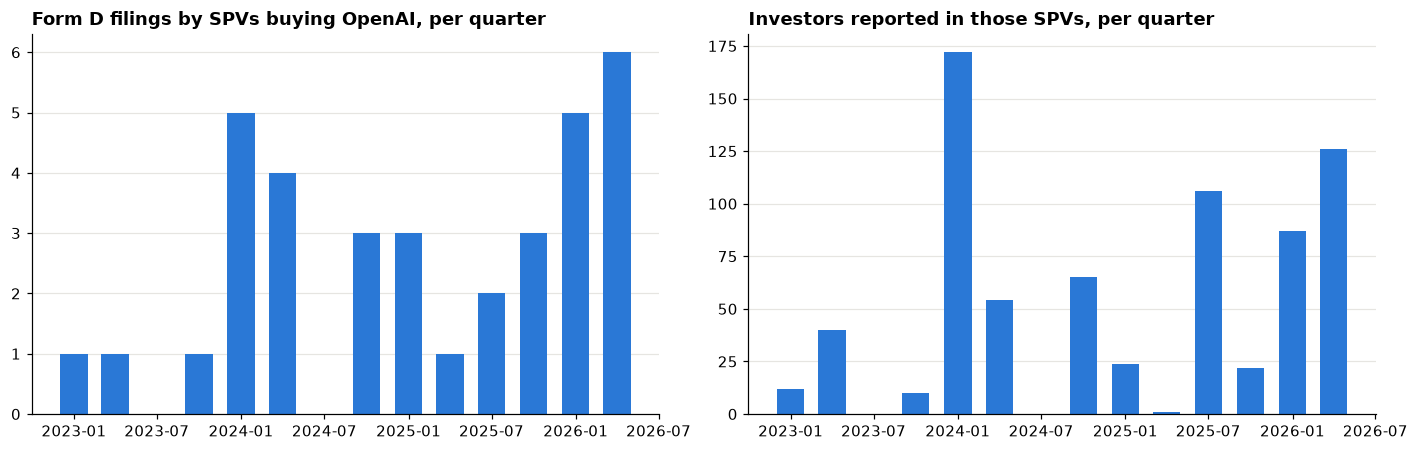

In [18]:
spvs = form_d[form_d["vehicle"] == "SPV buying OpenAI"]
by_q = (spvs.assign(q=spvs["filed"].dt.to_period("Q").dt.to_timestamp())
        .groupby("q").agg(filings=("issuer", "size"), investors=("investors", "sum")))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(by_q.index, by_q["filings"], width=60, color="#2a78d6")
axes[0].set_title("Form D filings by SPVs buying OpenAI, per quarter")
axes[0].yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
axes[1].bar(by_q.index, by_q["investors"], width=60, color="#2a78d6")
axes[1].set_title("Investors reported in those SPVs, per quarter")
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**What this run found:** the "OpenAI Startup Fund" entities are OpenAI's *own* venture arm raising money to invest
in startups. They make up 12 of the 47 filings but about **$754M of the $1.3B** reported sold (one $400M raise in
Aug 2026), which is why they are split out. The other 35 are secondary-market SPVs: about $551M from about 720
investors, with minimum tickets as low as $10k.

**How to read this.** Each SPV is a pool of accredited investors buying exposure to OpenAI. More filings, bigger
raises, and more investors per vehicle point to **rising secondary-market demand**, a sentiment gauge for a stock
that doesn't trade. Minimum tickets show *who* is buying (retail-accessible $10–25k SPVs vs. $250k+ institutional
vehicles). The same search works for any private company (e.g. `'"Anthropic"'`, `'"SpaceX"'`, `'"xAI"'`).
Caveats: Form D amounts are self-reported, many filers never file amendments, and name matching can miss vehicles
that don't include "OpenAI" in their name.

## 7. Insights: what makes EDGAR a great investment tool

EDGAR is free, official, timestamped to the second, and covers every US-registered issuer. Ranked by
signal-to-effort, here is what the notebook shows is worth building on:

### Tier 1: high-signal and easy to automate
1. **Form 4 open-market *purchases* (code P).** This is the most studied insider signal. Across this watchlist, mega-cap
   insiders almost never buy, so a **P** filing here would be rare and worth an alert. For mid and small caps,
   *clusters* of buyers (3+ insiders within 30 days) have historically been one of the strongest free signals.
2. **Discretionary sells vs. 10b5-1 sells.** Pre-planned sales are mostly noise. The `aff10b5_one` flag lets you filter
   them out automatically. Watch for discretionary sales that are large relative to the insider's remaining stake
   (`Remaining Shares` is on every Form 4).
3. **Form 144 notices.** These are filed *before* affiliate sales, so they lead the matching Form 4.
4. **8-K Item 5.02 (executive departures) and 2.02 (earnings) timing.** These are event triggers for re-rating.

### Tier 2: fundamentals at scale
5. **XBRL financials.** Standardized statements for every filer, back to 2009. Screens such as revenue acceleration,
   margin expansion, and `capex / operating cash flow` (the AI-capex theme in Section 4) run across the whole market,
   not just seven names.
6. **10-K text diffs.** Use lxml or edgartools' `.text()` to parse *Risk Factors* (Item 1A) and *MD&A* (Item 7), then diff
   year over year. New risk language, such as export controls for NVIDIA or data-center financing for Oracle, often
   shows up before it hits the numbers. This is where the `lxml` scraping in this project's name fits.

### Tier 3: positioning and private markets
7. **13F-HR.** A 45-day-lagged view of institutional positioning. Aggregate `compare_holdings()` across a list of active
   managers to find crowded or newly initiated trades.
8. **SC 13D / 13G.** A 13D means an **activist** crossed 5% with intent to influence. It's rare for mega-caps and a strong
   catalyst for smaller companies.
9. **Form D full-text search.** The only systematic window into private companies such as OpenAI. It's useful for
   AI-ecosystem sentiment and for spotting pre-IPO momentum.

### Suggested pipeline (next steps)
```
Daily (edgartools / EDGAR RSS)
  ├─ Form 4  → parse → filter P + discretionary S → cluster detector → Slack/email alert
  ├─ Form 144 → early-warning feed
  ├─ 8-K     → item 5.02 / 1.01 / 2.02 tagger
Quarterly
  ├─ 10-K/10-Q XBRL → fundamentals warehouse (DuckDB/Postgres) → screens
  ├─ 10-K text (lxml) → Risk Factor diff → new-risk report
  └─ 13F   → manager position deltas
```

### Caveats
* Insider **selling** is weak evidence alone. Founders (Huang, Ellison, Musk) sell for diversification and taxes on
  schedules set months in advance.
* 13F data lags by up to 45 days and shows only long US equity positions: no shorts, no bonds.
* EDGAR data is a **signal input, not a price model**. Pair it with market data (returns after each filing) to
  backtest whether a signal actually earned alpha before trading on it.
* The SEC rate limit is 10 requests/second and requires a User-Agent with contact info. edgartools handles both.